# COVID-Only vs UKR-Only vs COVID+UKR Merged

Compares the independently trained COVID-only and UKR-only checkpoints against the merged COVID+UKR checkpoint across the evaluated graph/task suite.

The notebook reads `covid_vs_ukr_vs_merged_eval_results.csv`, filters the merged model to one checkpoint by default, and plots a dataset/task grid with shots on the x-axis.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

CSV_NAME = "covid_vs_ukr_vs_merged_eval_results.csv"
CSV_PATH = Path(CSV_NAME)
if not CSV_PATH.exists():
    CSV_PATH = Path("scripts/experiments/analysis/archive/covid_vs_ukr_vs_merged") / CSV_NAME
CSV_PATH = CSV_PATH.resolve()

# Swap these when needed.
SPLIT = "test"
METRIC = "roc_auc"

# Merged eval CSV contains both 10k and 60k checkpoints. Use one for the
# clean three-way comparison: COVID-only, UKR-only, merged.
MERGED_CHECKPOINT = "60k"

SHOT_ORDER = [0, 3, 10]
DATASET_ORDER = [
    "covid19_twitter",
    "ukr_rus_twitter",
    "midterm",
    "covid_political",
    "election2020",
    "ukr_rus_suspended",
]
TASK_ORDER = ["nm", "lp", "pl"]
TASK_LABELS = {
    "nm": "Neighbor matching",
    "lp": "Temporal link prediction",
    "pl": "Classification",
}
TRAINING_ORDER = ["covid_only", "ukr_only", "merged_covid_ukr"]
TRAINING_LABELS = {
    "covid_only": "COVID-only",
    "ukr_only": "UKR-only",
    "merged_covid_ukr": f"COVID+UKR merged ({MERGED_CHECKPOINT})",
}
METRICS = ["accuracy", "f1", "roc_auc"]

In [16]:
raw = pd.read_csv(CSV_PATH)
raw["shots"] = raw["shots"].astype(int)

for col in METRICS:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

required = {"training_graph", "training_label", "checkpoint_label"}
missing = required - set(raw.columns)
if missing:
    raise ValueError(f"Combined CSV is missing columns: {sorted(missing)}")

unexpected_training = sorted(set(raw["training_graph"]) - set(TRAINING_ORDER))
unexpected_shots = sorted(set(raw["shots"]) - set(SHOT_ORDER))
if unexpected_training:
    raise ValueError(f"Unexpected training_graph values: {unexpected_training}")
if unexpected_shots:
    raise ValueError(f"Unexpected shot values: {unexpected_shots}")

single_dates = set(raw.loc[raw["training_graph"].isin(["covid_only", "ukr_only"]), "timestamp"].astype(str).str[:10])
if single_dates != {"15_06_2026"}:
    raise ValueError(f"COVID-only/UKR-only rows are not restricted to 15_06_2026: {sorted(single_dates)}")

df = raw[
    (raw["training_graph"] != "merged_covid_ukr")
    | (raw["checkpoint_label"].astype(str) == MERGED_CHECKPOINT)
].copy()

df["training_label"] = df["training_graph"].map(TRAINING_LABELS)
df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)
df["task"] = pd.Categorical(df["task"], categories=TASK_ORDER, ordered=True)
df["training_graph"] = pd.Categorical(df["training_graph"], categories=TRAINING_ORDER, ordered=True)
df["task_label"] = df["task"].astype(str).map(TASK_LABELS).fillna(df["task"].astype(str))
df = df.sort_values(["split", "dataset", "task", "training_graph", "shots"])

print(f"reading {CSV_PATH}")
print(f"raw rows: {len(raw)}; filtered rows: {len(df)}")
display(df.groupby(["training_graph", "shots"], observed=True).size().rename("rows").reset_index())
display(df.groupby(["dataset", "task", "shots"], observed=True).size().rename("models_present").reset_index().head(20))
display(df.head())

reading /Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/archive/covid_vs_ukr_vs_merged/covid_vs_ukr_vs_merged_eval_results.csv
raw rows: 134; filtered rows: 102


,training_graph,shots,rows
0,covid_only,0,12
1,covid_only,3,12
2,covid_only,10,12
3,ukr_only,0,12
4,ukr_only,3,12
5,ukr_only,10,12
6,merged_covid_ukr,0,9
7,merged_covid_ukr,3,9
8,merged_covid_ukr,10,12


,dataset,task,shots,models_present
0,covid19_twitter,nm,0,3
1,covid19_twitter,nm,3,3
2,covid19_twitter,nm,10,3
3,covid19_twitter,lp,0,3
4,covid19_twitter,lp,3,3
5,covid19_twitter,lp,10,3
6,ukr_rus_twitter,nm,0,3
7,ukr_rus_twitter,nm,3,3
8,ukr_rus_twitter,nm,10,3
9,ukr_rus_twitter,lp,0,3


,run_name,model,checkpoint,dataset,task,task_name,shots,timestamp,split,run_dir,metrics_path,accuracy,f1,roc_auc,source_csv,training_graph,training_label,checkpoint_label,task_label
101,eval_covid_only_nm_14_06_2026_16_38_56_to_covi...,covid_only_nm_14_06_2026_16_38_56,56,covid19_twitter,nm,neighbor_matching,0,15_06_2026_09_01_55,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.330389,0.299720,0.501085,scripts/experiments/analysis/archive/covid_only_ukr_only/covid_ukr...,covid_only,COVID-only,covid_only,Neighbor matching
102,eval_covid_only_nm_14_06_2026_16_38_56_to_covi...,covid_only_nm_14_06_2026_16_38_56,56,covid19_twitter,nm,neighbor_matching,3,15_06_2026_09_01_57,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.928722,0.928716,0.991444,scripts/experiments/analysis/archive/covid_only_ukr_only/covid_ukr...,covid_only,COVID-only,covid_only,Neighbor matching
103,eval_covid_only_nm_14_06_2026_16_38_56_to_covi...,covid_only_nm_14_06_2026_16_38_56,56,covid19_twitter,nm,neighbor_matching,10,15_06_2026_09_10_22,test,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,/dataMeR2/phil/gfm/prodigy/log/eval_covid_only...,0.955444,0.955448,0.996677,scripts/experiments/analysis/archive/covid_only_ukr_only/covid_ukr...,covid_only,COVID-only,covid_only,Neighbor matching
65,eval_ukr_only_nm_14_06_2026_16_39_00_to_covid1...,ukr_only_nm_14_06_2026_16_39_00,00,covid19_twitter,nm,neighbor_matching,0,15_06_2026_09_05_10,test,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,0.335278,0.302790,0.496375,scripts/experiments/analysis/archive/covid_only_ukr_only/covid_ukr...,ukr_only,UKR-only,ukr_only,Neighbor matching
66,eval_ukr_only_nm_14_06_2026_16_39_00_to_covid1...,ukr_only_nm_14_06_2026_16_39_00,00,covid19_twitter,nm,neighbor_matching,3,15_06_2026_09_05_23,test,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,/dataMeR2/phil/gfm/prodigy/log/eval_ukr_only_n...,0.909278,0.909286,0.985562,scripts/experiments/analysis/archive/covid_only_ukr_only/covid_ukr...,ukr_only,UKR-only,ukr_only,Neighbor matching


In [ ]:
eval_covid_only_nm_14_06_2026_16_38_56_to_covid19_twitter_nm_0shot_15_06_2026_09_01_55:
    state/covid_only_nm_14_06_2026_16_38_56/checkpoint/state_dict_100000.ckpt
    
eval_ukr_only_nm_14_06_2026_16_39_00_to_covid19_twitter_nm_0shot_15_06_2026_09_05_10:
    state/ukr_only_nm_14_06_2026_16_39_00/checkpoint/state_dict_100000.ckpt
    
eval_merged_ukr_rus_covid_nm_60k_to_covid19_twitter_nm_0shot_12_06_2026_01_07_40:
    state/merged_ukr_rus_covid_nm_11_06_2026_18_55_40/checkpoint/state_dict_60000.ckpt


In [33]:
df.drop_duplicates(['model']).run_name.values

<ArrowStringArray>
['eval_covid_only_nm_14_06_2026_16_38_56_to_covid19_twitter_nm_0shot_15_06_2026_09_01_55',
   'eval_ukr_only_nm_14_06_2026_16_39_00_to_covid19_twitter_nm_0shot_15_06_2026_09_05_10',
       'eval_merged_ukr_rus_covid_nm_60k_to_covid19_twitter_nm_0shot_12_06_2026_01_07_40']
Length: 3, dtype: str

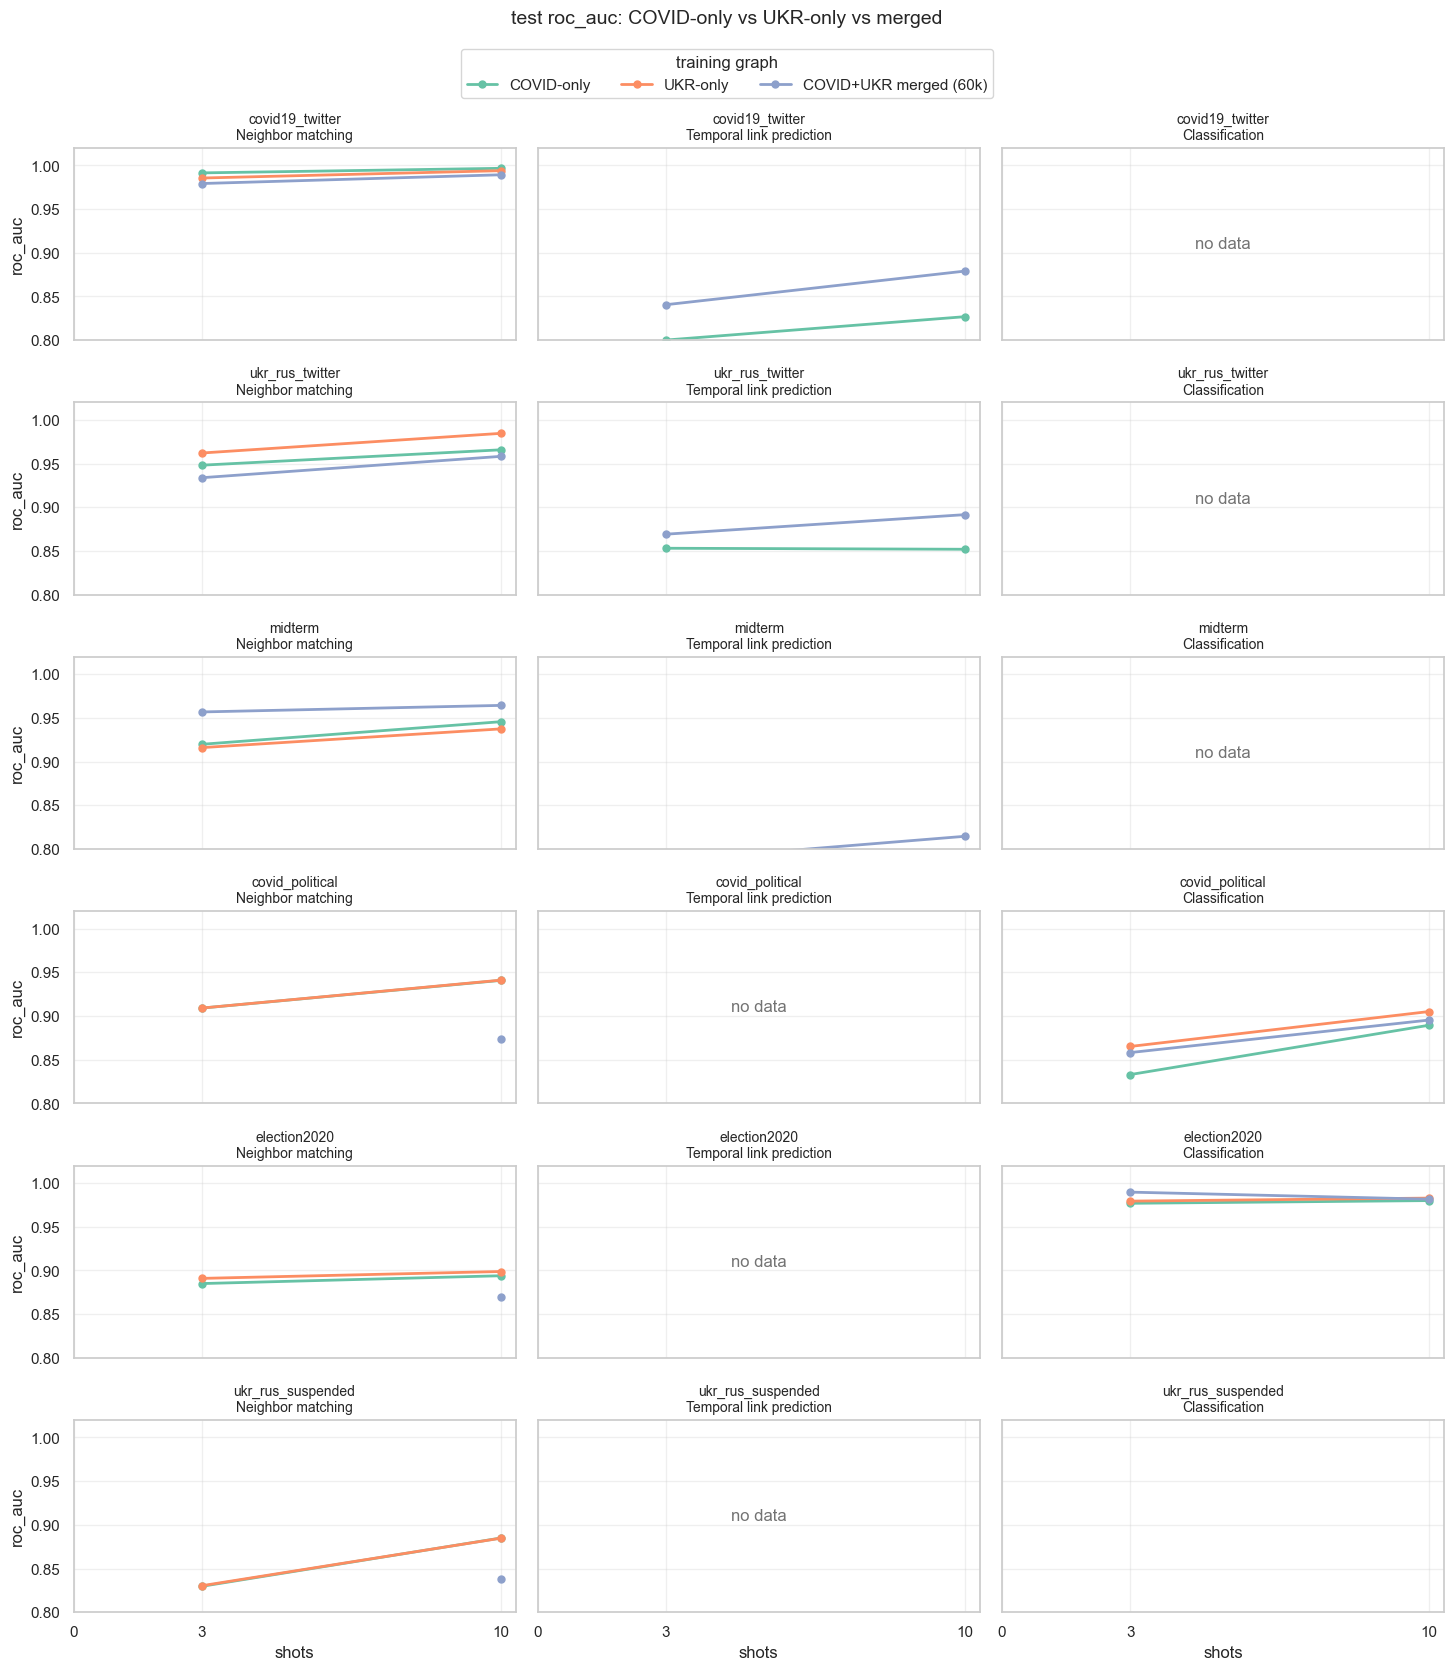

In [21]:
def plot_metric_grid(data, *, split=SPLIT, metric=METRIC, datasets=DATASET_ORDER, tasks=TASK_ORDER):
    subset = data[(data["split"] == split) & data[metric].notna()].copy()
    if subset.empty:
        raise ValueError(f"No rows for split={split!r}, metric={metric!r}")

    palette = dict(zip(TRAINING_ORDER, sns.color_palette("Set2", n_colors=len(TRAINING_ORDER))))

    fig, axes = plt.subplots(
        nrows=len(datasets),
        ncols=len(tasks),
        figsize=(4.9 * len(tasks), 2.7 * len(datasets)),
        sharex=True,
        sharey=True,
    )

    if len(datasets) == 1 and len(tasks) == 1:
        axes = [[axes]]
    elif len(datasets) == 1:
        axes = [axes]
    elif len(tasks) == 1:
        axes = [[ax] for ax in axes]

    for row_idx, dataset in enumerate(datasets):
        for col_idx, task in enumerate(tasks):
            ax = axes[row_idx][col_idx]
            panel = subset[(subset["dataset"].astype(str) == dataset) & (subset["task"].astype(str) == task)]
            task_label = TASK_LABELS.get(task, task)
            ax.set_title(f"{dataset}\n{task_label}", fontsize=10)

            if panel.empty:
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center", color="0.45")
            else:
                for training_graph in TRAINING_ORDER:
                    line = panel[panel["training_graph"].astype(str) == training_graph].sort_values("shots")
                    if line.empty:
                        continue
                    ax.plot(
                        line["shots"],
                        line[metric],
                        marker="o",
                        linewidth=2,
                        markersize=5,
                        label=TRAINING_LABELS.get(training_graph, training_graph),
                        color=palette[training_graph],
                    )

            ax.set_ylim(0.8, 1.02)
            ax.set_xticks(SHOT_ORDER)
            ax.grid(True, alpha=0.3)
            if row_idx == len(datasets) - 1:
                ax.set_xlabel("shots")
            else:
                ax.set_xlabel("")
            if col_idx == 0:
                ax.set_ylabel(metric)
            else:
                ax.set_ylabel("")

    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    if handles:
        fig.legend(handles, labels, title="training graph", loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.01))

    fig.suptitle(f"{split} {metric}: COVID-only vs UKR-only vs merged", y=1.03, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_metric_grid(df[df.shots.isin([3,10])], split=SPLIT, metric=METRIC)

In [18]:
# Side-by-side metric table. Missing cells usually mean that eval did not run,
# failed, or was not supported for that graph/task.
table = (
    df[df["split"] == SPLIT]
    .pivot_table(
        index=["dataset", "task", "shots"],
        columns="training_label",
        values=METRIC,
        observed=True,
    )
    .reset_index()
    .sort_values(["dataset", "task", "shots"])
)

cols = [TRAINING_LABELS[key] for key in TRAINING_ORDER]
available = [col for col in cols if col in table.columns]
merged_col = TRAINING_LABELS["merged_covid_ukr"]
if merged_col in table.columns:
    if "COVID-only" in table.columns:
        table["merged - COVID-only"] = table[merged_col] - table["COVID-only"]
    if "UKR-only" in table.columns:
        table["merged - UKR-only"] = table[merged_col] - table["UKR-only"]

display(table)

training_label,dataset,task,shots,COVID+UKR merged (60k),COVID-only,UKR-only,merged - COVID-only,merged - UKR-only
0,covid19_twitter,nm,0,0.493690,0.501085,0.496375,-0.007395,-0.002685
1,covid19_twitter,nm,3,0.979262,0.991444,0.985562,-0.012182,-0.006300
2,covid19_twitter,nm,10,0.989270,0.996677,0.993975,-0.007407,-0.004705
3,covid19_twitter,lp,0,0.608607,0.573105,0.536590,0.035503,0.072018
4,covid19_twitter,lp,3,0.840580,0.800131,0.667467,0.040449,0.173113
5,covid19_twitter,lp,10,0.879051,0.826891,0.595960,0.052160,0.283090
6,ukr_rus_twitter,nm,0,0.488788,0.499642,0.494095,-0.010855,-0.005307
7,ukr_rus_twitter,nm,3,0.933744,0.948080,0.962007,-0.014336,-0.028263
8,ukr_rus_twitter,nm,10,0.958171,0.965672,0.984497,-0.007501,-0.026326
9,ukr_rus_twitter,lp,0,0.614934,0.607508,0.579021,0.007426,0.035913


In [19]:
# Coverage diagnostics for the selected merged checkpoint.
coverage = (
    df.groupby(["dataset", "task", "shots", "training_label"], observed=True)
      .size()
      .rename("rows")
      .reset_index()
      .pivot_table(
          index=["dataset", "task", "shots"],
          columns="training_label",
          values="rows",
          fill_value=0,
          observed=True,
      )
      .reset_index()
      .sort_values(["dataset", "task", "shots"])
)

display(coverage)
display(coverage[(coverage[[col for col in coverage.columns if col not in {"dataset", "task", "shots"}]] == 0).any(axis=1)])

training_label,dataset,task,shots,COVID+UKR merged (60k),COVID-only,UKR-only
0,covid19_twitter,nm,0,1.0,1.0,1.0
1,covid19_twitter,nm,3,1.0,1.0,1.0
2,covid19_twitter,nm,10,1.0,1.0,1.0
3,covid19_twitter,lp,0,1.0,1.0,1.0
4,covid19_twitter,lp,3,1.0,1.0,1.0
5,covid19_twitter,lp,10,1.0,1.0,1.0
6,ukr_rus_twitter,nm,0,1.0,1.0,1.0
7,ukr_rus_twitter,nm,3,1.0,1.0,1.0
8,ukr_rus_twitter,nm,10,1.0,1.0,1.0
9,ukr_rus_twitter,lp,0,1.0,1.0,1.0


training_label,dataset,task,shots,COVID+UKR merged (60k),COVID-only,UKR-only
18,covid_political,nm,0,0.0,1.0,1.0
19,covid_political,nm,3,0.0,1.0,1.0
24,election2020,nm,0,0.0,1.0,1.0
25,election2020,nm,3,0.0,1.0,1.0
30,ukr_rus_suspended,nm,0,0.0,1.0,1.0
31,ukr_rus_suspended,nm,3,0.0,1.0,1.0


In [20]:
# Long-form table for export/copying.
long_table = (
    df[df["split"] == SPLIT]
    [["dataset", "task", "training_label", "shots", METRIC, "run_name"]]
    .sort_values(["dataset", "task", "training_label", "shots"])
)
display(long_table)

,dataset,task,training_label,shots,roc_auc,run_name
35,covid19_twitter,nm,COVID+UKR merged (60k),0,0.493690,eval_merged_ukr_rus_covid_nm_60k_to_covid19_tw...
36,covid19_twitter,nm,COVID+UKR merged (60k),3,0.979262,eval_merged_ukr_rus_covid_nm_60k_to_covid19_tw...
37,covid19_twitter,nm,COVID+UKR merged (60k),10,0.989270,eval_merged_ukr_rus_covid_nm_60k_to_covid19_tw...
101,covid19_twitter,nm,COVID-only,0,0.501085,eval_covid_only_nm_14_06_2026_16_38_56_to_covi...
102,covid19_twitter,nm,COVID-only,3,0.991444,eval_covid_only_nm_14_06_2026_16_38_56_to_covi...
...,...,...,...,...,...,...
126,ukr_rus_suspended,pl,COVID-only,3,0.504872,eval_covid_only_nm_14_06_2026_16_38_56_to_ukr_...
127,ukr_rus_suspended,pl,COVID-only,10,0.505802,eval_covid_only_nm_14_06_2026_16_38_56_to_ukr_...
89,ukr_rus_suspended,pl,UKR-only,0,0.498430,eval_ukr_only_nm_14_06_2026_16_39_00_to_ukr_ru...
90,ukr_rus_suspended,pl,UKR-only,3,0.509968,eval_ukr_only_nm_14_06_2026_16_39_00_to_ukr_ru...
